## Logistic Regression

Train, validation, test: 48000 12000 10000
Validation accuracy: 0.8616
Test accuracy: 0.8411
              precision    recall  f1-score   support

 T-shirt/top       0.80      0.80      0.80      1000
     Trouser       0.97      0.96      0.96      1000
    Pullover       0.73      0.73      0.73      1000
       Dress       0.83      0.85      0.84      1000
        Coat       0.74      0.76      0.75      1000
      Sandal       0.94      0.93      0.93      1000
       Shirt       0.61      0.57      0.59      1000
     Sneaker       0.92      0.93      0.92      1000
         Bag       0.93      0.93      0.93      1000
  Ankle boot       0.94      0.95      0.95      1000

    accuracy                           0.84     10000
   macro avg       0.84      0.84      0.84     10000
weighted avg       0.84      0.84      0.84     10000



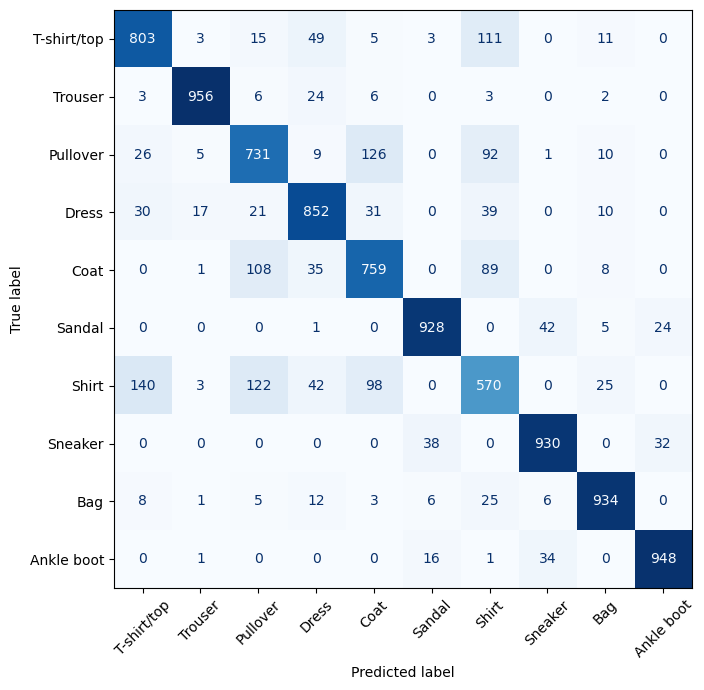

In [1]:
# Block 1: add the matching comment
import matplotlib.pyplot as plt
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import tensorflow as tf
tf.config.set_visible_devices([], "GPU")  # use the CPU; Metal is slower and inaccurate for these models


keras.utils.set_random_seed(42)
# Block 2: add the matching comment
(X, y), (X_test_full, y_test_full) = keras.datasets.fashion_mnist.load_data()
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot",
]

# Block 3: add the matching comment
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
X_test, y_test = X_test_full, y_test_full
X_train = (X_train.astype("float32") / 255.0).reshape(len(X_train), 784)
X_val = (X_val.astype("float32") / 255.0).reshape(len(X_val), 784)
X_test = (X_test.astype("float32") / 255.0).reshape(len(X_test), 784)

# Block 4: add the matching comment
logistic_model = LogisticRegression(max_iter=3000, random_state=42)
logistic_model.fit(X_train, y_train)
# Block 5: add the matching comment
lr_validation_accuracy = accuracy_score(y_val, logistic_model.predict(X_val))
# Block 6: add the matching comment
lr_predictions = logistic_model.predict(X_test)
lr_test_accuracy = accuracy_score(y_test, lr_predictions)

print("Train, validation, test:", len(X_train), len(X_val), len(X_test))
print("Validation accuracy:", round(lr_validation_accuracy, 4))
print("Test accuracy:", round(lr_test_accuracy, 4))
print(classification_report(y_test, lr_predictions, target_names=class_names, zero_division=0))
fig, ax = plt.subplots(figsize=(9, 7))
ConfusionMatrixDisplay.from_predictions(
    y_test, lr_predictions, display_labels=class_names,
    xticks_rotation=45, cmap="Blues", colorbar=False, ax=ax
)
plt.tight_layout()
plt.show()

## Random Forrest

Train, validation, test: 48000 12000 10000
Validation accuracy: 0.8812
Test accuracy: 0.8746
              precision    recall  f1-score   support

 T-shirt/top       0.82      0.86      0.84      1000
     Trouser       0.99      0.96      0.98      1000
    Pullover       0.76      0.79      0.78      1000
       Dress       0.87      0.91      0.89      1000
        Coat       0.76      0.81      0.79      1000
      Sandal       0.98      0.95      0.97      1000
       Shirt       0.71      0.59      0.64      1000
     Sneaker       0.93      0.95      0.94      1000
         Bag       0.96      0.97      0.97      1000
  Ankle boot       0.95      0.95      0.95      1000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



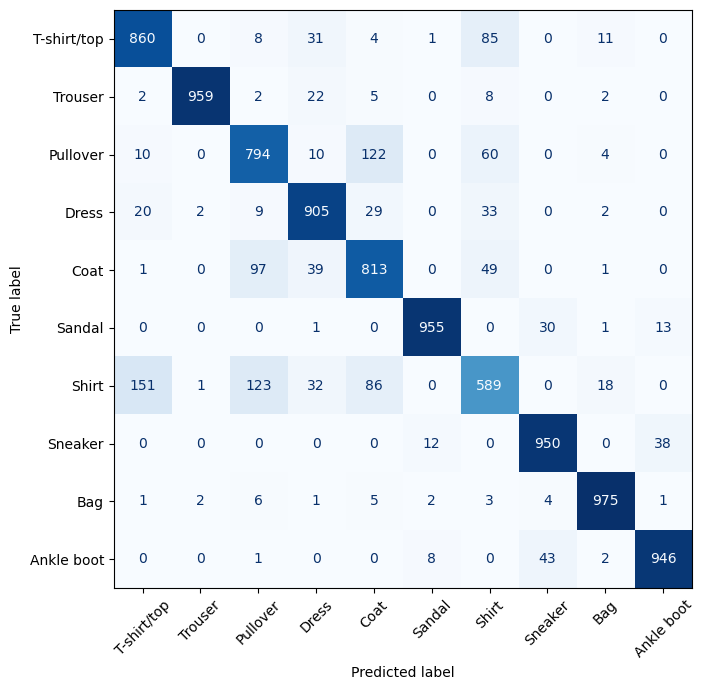

In [2]:
# Block 1: add the matching comment
import matplotlib.pyplot as plt
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

keras.utils.set_random_seed(42)
# Block 2: add the matching comment
(X, y), (X_test_full, y_test_full) = keras.datasets.fashion_mnist.load_data()
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot",
]

# Block 3: add the matching comment
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
X_test, y_test = X_test_full, y_test_full
X_train = (X_train.astype("float32") / 255.0).reshape(len(X_train), 784)
X_val = (X_val.astype("float32") / 255.0).reshape(len(X_val), 784)
X_test = (X_test.astype("float32") / 255.0).reshape(len(X_test), 784)

# Block 4: add the matching comment
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=1)
rf_model.fit(X_train, y_train)
# Block 5: add the matching comment
rf_validation_accuracy = accuracy_score(y_val, rf_model.predict(X_val))
# Block 6: add the matching comment
rf_predictions = rf_model.predict(X_test)
rf_test_accuracy = accuracy_score(y_test, rf_predictions)

print("Train, validation, test:", len(X_train), len(X_val), len(X_test))
print("Validation accuracy:", round(rf_validation_accuracy, 4))
print("Test accuracy:", round(rf_test_accuracy, 4))
print(classification_report(y_test, rf_predictions, target_names=class_names, zero_division=0))
fig, ax = plt.subplots(figsize=(9, 7))
ConfusionMatrixDisplay.from_predictions(
    y_test, rf_predictions, display_labels=class_names,
    xticks_rotation=45, cmap="Blues", colorbar=False, ax=ax
)
plt.tight_layout()
plt.show()

## Simple Neural Networks

X shape: (60000, 28, 28)
y shape: (60000,)
Classes: [0 1 2 3 4 5 6 7 8 9]
Official test shape: (10000, 28, 28)


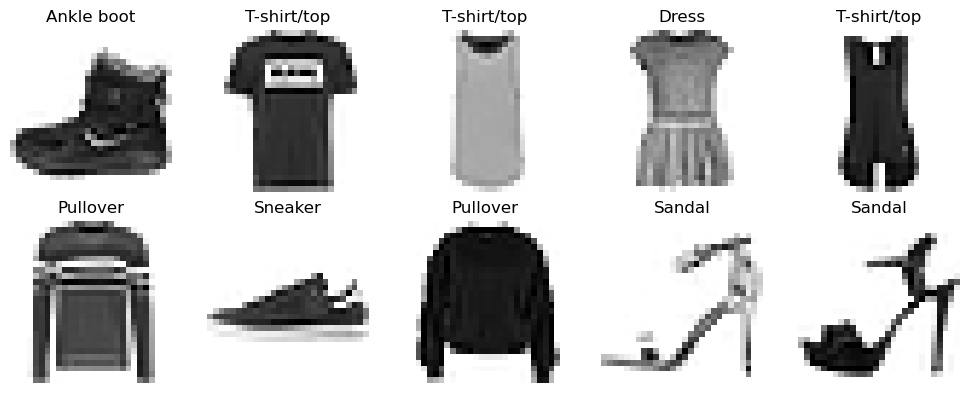

,count
T-shirt/top,6000
Trouser,6000
Pullover,6000
Dress,6000
Coat,6000
Sandal,6000
Shirt,6000
Sneaker,6000
Bag,6000
Ankle boot,6000


In [ ]:
# Block 1: add the matching comment
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)

# Block 2: add the matching comment
keras.utils.set_random_seed(42)

# Block 3: add the matching comment
(X, y), (X_test_full, y_test_full) = keras.datasets.fashion_mnist.load_data()
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot",
]

# Block 4: add the matching comment
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Classes:", np.unique(y))
print("Official test shape:", X_test_full.shape)

# Block 1: add the matching comment
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

# Block 2: add the matching comment
for i, ax in enumerate(axes.ravel()):
    ax.imshow(X[i], cmap="gray_r")
    ax.set_title(class_names[y[i]])
    ax.axis("off")

plt.tight_layout()
plt.show()

# Block 3: add the matching comment
class_counts = pd.Series(y).value_counts().sort_index()
class_counts.index = [class_names[i] for i in class_counts.index]
display(class_counts.to_frame("count"))

# Block 1: add the matching comment
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y,
)
# Block 2: add the matching comment
X_test, y_test = X_test_full, y_test_full

# Block 3: add the matching comment
X_train = X_train.astype("float32") / 255.0
X_val = X_val.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Block 4: add the matching comment
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

In [5]:
# Block 1: add the matching comment
model = keras.Sequential([
    keras.Input(shape=(28, 28)),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax"),
])

# Block 2: add the matching comment
model.summary()

model.compile(
    # Block 1: add the matching comment
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),
    # Block 2: add the matching comment
    loss="sparse_categorical_crossentropy",
    # Block 3: add the matching comment
    metrics=["accuracy"],
)

# Block 1: add the matching comment
history = model.fit(
    X_train,
    y_train,
    # Block 2: add the matching comment
    validation_data=(X_val, y_val),
    # Block 3: add the matching comment
    epochs=20,
    batch_size=32,
    verbose=1,
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,890 (198.79 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 797us/step - accuracy: 0.8099 - loss: 0.5436 - val_accuracy: 0.8367 - val_loss: 0.4518
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 752us/step - accuracy: 0.8554 - loss: 0.4056 - val_accuracy: 0.8654 - val_loss: 0.3785
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 729us/step - accuracy: 0.8683 - loss: 0.3650 - val_accuracy: 0.8725 - val_loss: 0.3563
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 751us/step - accuracy: 0.8774 - loss: 0.3378 - val_accuracy: 0.8774 - val_loss: 0.3439
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 749us/step - accuracy: 0.8843 - loss: 0.3182 - val_accuracy: 0.8785 - val_loss: 0.3416
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 743us/step - accuracy: 0.8895 - loss: 0.3032 - val_accuracy: 0.8792 - val_loss: 0.3419
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 767us/step - accuracy: 0.8946 - loss: 0.2899 - val_accuracy: 0.8793 - val_loss: 0.3377
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 762us/step - accuracy: 0.8986 -

Test loss: 0.4226
Test accuracy: 0.8667
Accuracy: 0.8667
              precision    recall  f1-score   support

 T-shirt/top       0.86      0.76      0.81      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.67      0.88      0.76      1000
       Dress       0.87      0.88      0.87      1000
        Coat       0.84      0.67      0.75      1000
      Sandal       0.97      0.96      0.96      1000
       Shirt       0.66      0.68      0.67      1000
     Sneaker       0.92      0.97      0.95      1000
         Bag       0.97      0.96      0.96      1000
  Ankle boot       0.97      0.94      0.96      1000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



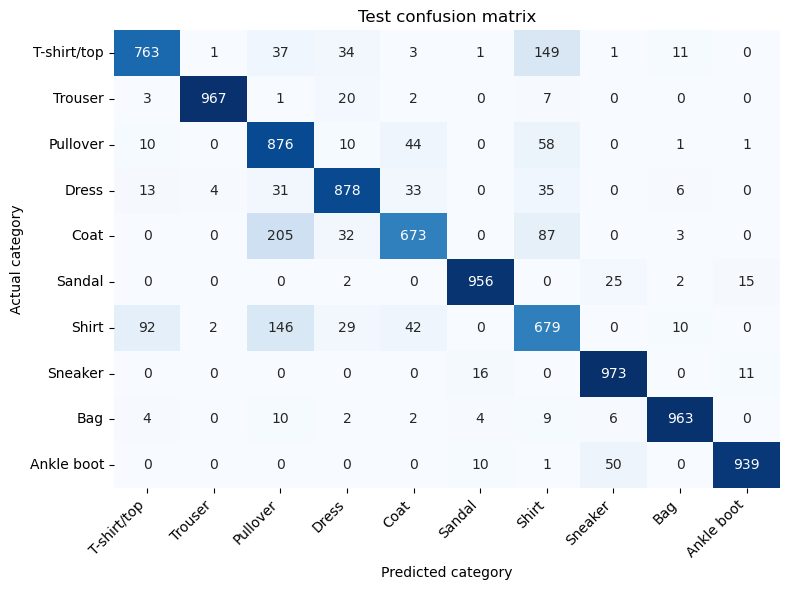

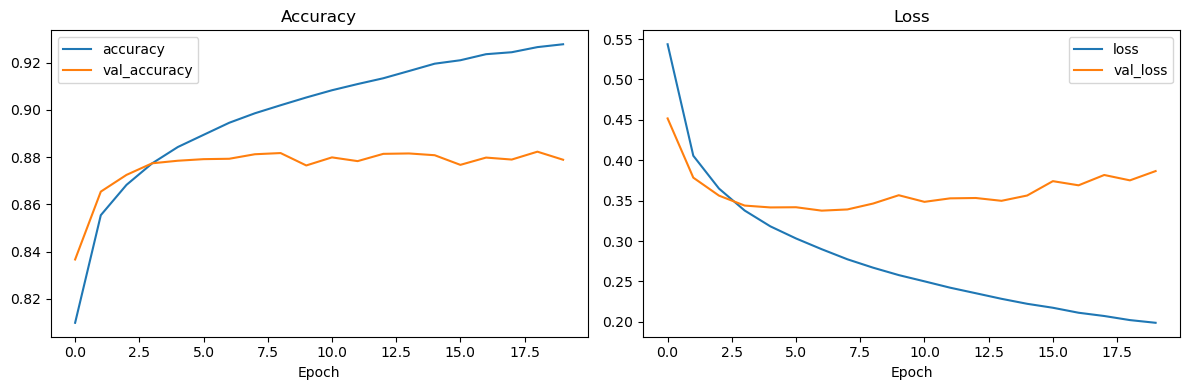

In [6]:
# Block 1: add the matching comment
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0,
)

# Block 2: add the matching comment
print("Test loss:", round(test_loss, 4))
print("Test accuracy:", round(test_accuracy, 4))

# Block 1: add the matching comment
probabilities = model.predict(
    X_test,
    verbose=0,
)
y_pred = np.argmax(probabilities, axis=1)

# Block 2: add the matching comment
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

# Block 3: add the matching comment
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.xlabel("Predicted category")
plt.ylabel("Actual category")
plt.title("Test confusion matrix")
plt.tight_layout()
plt.show()

# Block 1: add the matching comment
history_df = pd.DataFrame(history.history)

# Block 2: add the matching comment
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Block 3: add the matching comment
history_df[["accuracy", "val_accuracy"]].plot(
    ax=axes[0],
    title="Accuracy",
)
history_df[["loss", "val_loss"]].plot(
    ax=axes[1],
    title="Loss",
)

# Block 4: add the matching comment
axes[0].set_xlabel("Epoch")
axes[1].set_xlabel("Epoch")
plt.tight_layout()
plt.show()

